In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética global
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


Reto 1: Exploración Inicial

In [4]:
# Nota: Asegúrate de descargar el archivo 'titanic.csv' de Kaggle y subirlo a tu entorno de Colab
df = pd.read_csv('/content/Titanic-Dataset.csv')

print("--- Primeras Filas ---")
print(df.head())

print("\n--- Dimensiones del Dataset ---")
print(df.shape)

print("\n--- Información General ---")
df.info()

print("\n--- Conteo de Valores Nulos ---")
print(df.isnull().sum())

print("\n--- Resumen Estadístico ---")
print(df.describe(include='all'))

--- Primeras Filas ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0

Reto 1:
* ¿Cuántos pasajeros y cuántas columnas tiene el dataset? El dataset cuenta con 891 filas (pasajeros) y 12 columnas (variables).  

* ¿Qué variables son numéricas y cuáles son categóricas?   

* Numéricas: PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare.  

* Categóricas: Name, Sex, Ticket, Cabin, Embarked.  

* ¿Qué tipo de dato tiene cada columna? int64 para identificadores y conteos enteros, float64 para variables continuas (Age, Fare), y object para cadenas de texto.  

* ¿Hay valores nulos? ¿En qué columnas? Sí, principalmente en Age (177 nulos), Cabin (687 nulos) y Embarked (2 nulos).  

* ¿Qué porcentaje de pasajeros sobrevivió? Aproximadamente el 38.38% del total de los pasajeros registrados en este dataset.  

**PARTE I: El Perfil de los PasajerosPregunta 1**:

* ¿Cómo era la composición del pasaje? (Markdown)Justificación del gráfico: Se utilizará un Gráfico de barras (Countplot).
Al tratarse de una variable categórica ordinal (Pclass), este gráfico permite comparar de forma directa y visual el volumen absoluto de personas en cada clase, identificando cuál era la dominante.  

/tmp/ipykernel_1226/1470883251.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Pclass', palette='viridis')
/tmp/ipykernel_1226/1470883251.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['1ª Clase', '2ª Clase', '3ª Clase'])


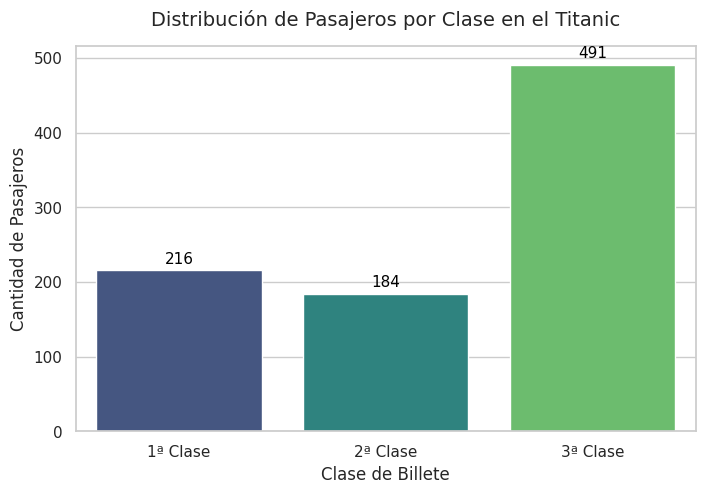

In [5]:
# Código Python - Pregunta 1
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Pclass', palette='viridis')

plt.title('Distribución de Pasajeros por Clase en el Titanic', pad=15)
plt.xlabel('Clase de Billete')
plt.ylabel('Cantidad de Pasajeros')
ax.set_xticklabels(['1ª Clase', '2ª Clase', '3ª Clase'])

# Añadir etiquetas de valor sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

**Interpretación**: El Titanic no era un barco igualitario. La gran mayoría de los pasajeros viajaba en Tercera Clase, superando la suma de la Primera y Segunda Clase juntas. Esto refleja que el modelo de negocio dependía fuertemente del volumen de inmigrantes y pasajeros de bajos recursos.  

**Pregunta 2**:

¿Qué edades tenían los pasajeros?
Justificación del gráfico: Utilizaremos un Histograma con estimación de densidad de kernel (KDE). Es el gráfico ideal para analizar la distribución de una variable numérica continua (Age), permitiendo identificar sesgos, asimetrías y modas visuales.

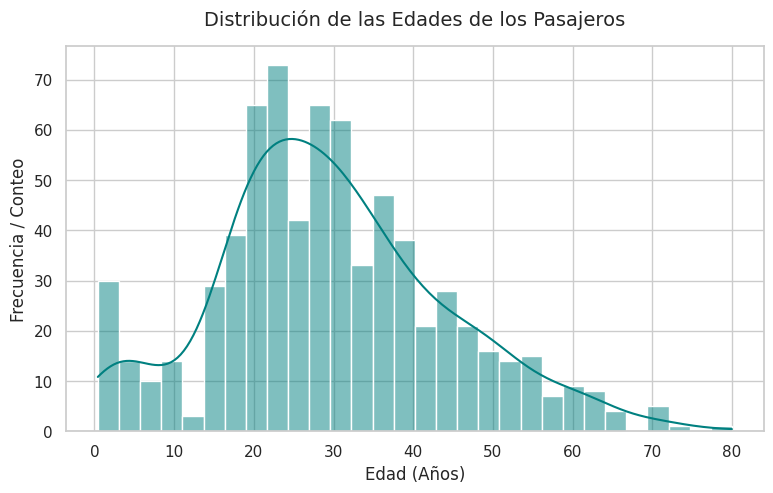

In [6]:
# Código Python - Pregunta 2
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='Age', kde=True, bins=30, color='teal')

plt.title('Distribución de las Edades de los Pasajeros', pad=15)
plt.xlabel('Edad (Años)')
plt.ylabel('Frecuencia / Conteo')

plt.show()

**Interpretación**: El pasaje era predominantemente joven-adulto, concentrándose la mayor parte de la población entre los 20 y los 40 años. Hay una presencia notable de niños pequeños (visible en el pico inicial de la izquierda), lo que confirma el perfil de familias que emigraban juntas. Los valores extremos hacia los 80 años son muy escasos

**Pregunta 3**: ¿Existía diferencia de edad entre clases sociales? (Markdown)
Justificación del gráfico: Se opta por un Diagrama de Caja (Boxplot) combinado con una distribución por clase. Permite comparar simultáneamente la mediana, los cuartiles y la dispersión de las edades en los tres grupos independientes.

/tmp/ipykernel_1226/3081072968.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Age', palette='Set2')


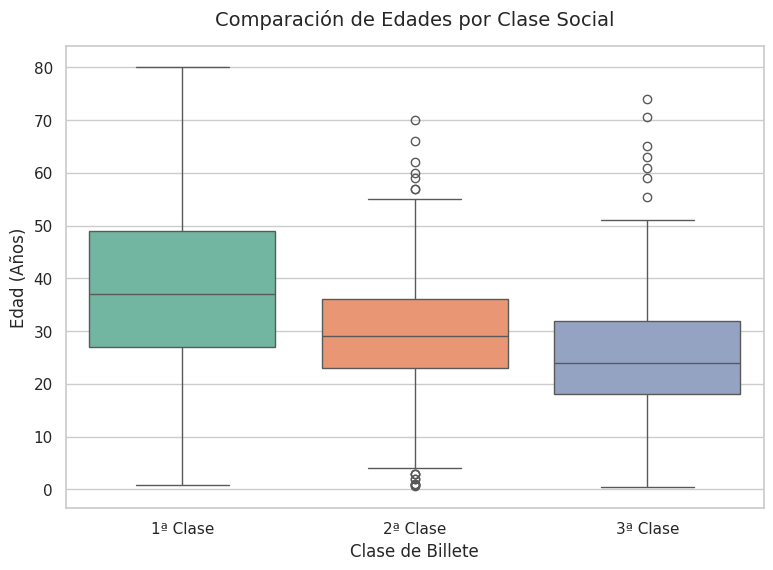

In [7]:
# Código Python - Pregunta 3
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='Pclass', y='Age', palette='Set2')

plt.title('Comparación de Edades por Clase Social', pad=15)
plt.xlabel('Clase de Billete')
plt.ylabel('Edad (Años)')
plt.xticks([0, 1, 2], ['1ª Clase', '2ª Clase', '3ª Clase'])

plt.show()

**Interpretación**: Se observa una clara relación jerárquica entre la edad y la clase social. La Primera Clase muestra una mediana de edad significativamente más alta (cercana a los 40 años), confirmando que eran personas económicamente establecidas. En contraste, la Tercera Clase es notablemente más joven (mediana cercana a los 25 años), consistente con el perfil de jóvenes emigrantes.

**PARTE II: El Dinero a Bordo**


**Pregunta 4**: ¿Cuánto se pagó por viajar en el Titanic?

Justificación del gráfico: Un Histograma es la mejor herramienta para evaluar la distribución de la tarifa (Fare). Dado que existen valores extremadamente altos (valores atípicos), la representación ayudará a observar la asimetría del dinero pagado.

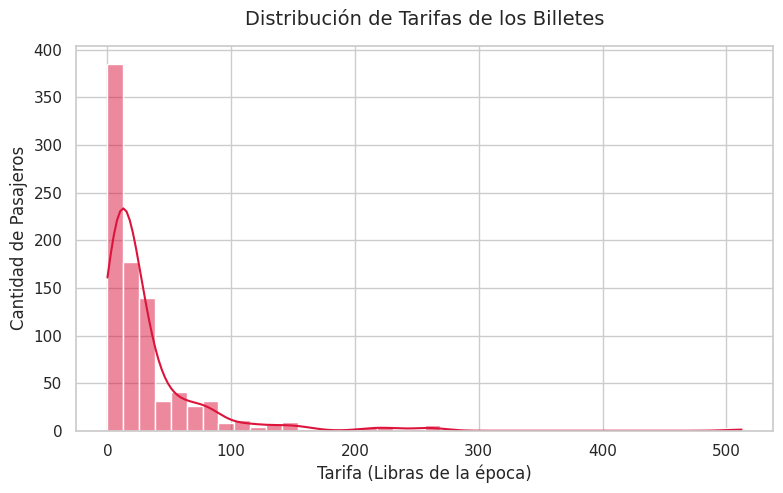

In [8]:
# Código Python - Pregunta 4
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='Fare', bins=40, color='crimson', kde=True)

plt.title('Distribución de Tarifas de los Billetes', pad=15)
plt.xlabel('Tarifa (Libras de la época)')
plt.ylabel('Cantidad de Pasajeros')

plt.show()

**Interpretación**: La distribución sufre de una asimetría positiva extrema. La inmensa mayoría de los pasajeros pagó tarifas muy bajas (menos de 25-50 libras). Sin embargo, la escala se extiende hasta más de 500 libras debido a un número muy reducido de billetes de super-lujo, lo que demuestra una brecha económica abismal a bordo.

**Pregunta 5**: ¿La clase social determinaba cuánto se pagaba?

Justificación del gráfico: Un Diagrama de Caja y Bigotes (Boxplot) segmentado por Pclass. Es ideal para evaluar la variabilidad, los rangos intercuartílicos y los valores atípicos específicos dentro de cada nivel social.

/tmp/ipykernel_1226/3448237023.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='magma')


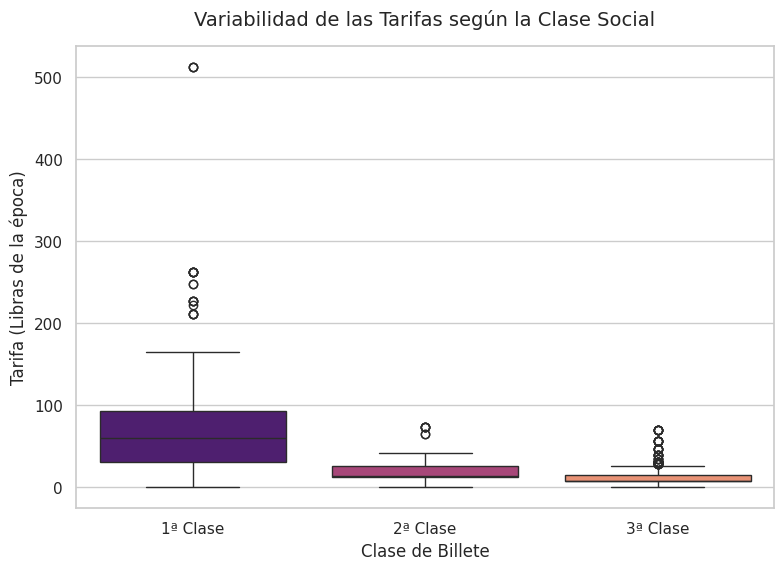

In [9]:
# Código Python - Pregunta 5
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='Pclass', y='Fare', palette='magma')

plt.title('Variabilidad de las Tarifas según la Clase Social', pad=15)
plt.xlabel('Clase de Billete')
plt.ylabel('Tarifa (Libras de la época)')
plt.xticks([0, 1, 2], ['1ª Clase', '2ª Clase', '3ª Clase'])

plt.show()

**Interpretación**: Evidentemente la Primera Clase pagaba tarifas mucho más altas, pero lo más sorprendente es su enorme variabilidad interna. Mientras que en Segunda y Tercera Clase los precios eran uniformes y compactos, en Primera Clase existían diferencias colosales: desde billetes estándar hasta suites presidenciales que constituyen los valores atípicos superiores.

**Pregunta 6**: ¿La riqueza está relacionada con la edad?
Justificación del gráfico: Un Gráfico de Dispersión (Scatter Plot). Es el método estándar para evaluar la relación cuantitativa y los patrones de correlación entre dos variables numéricas continuas (Age vs Fare).

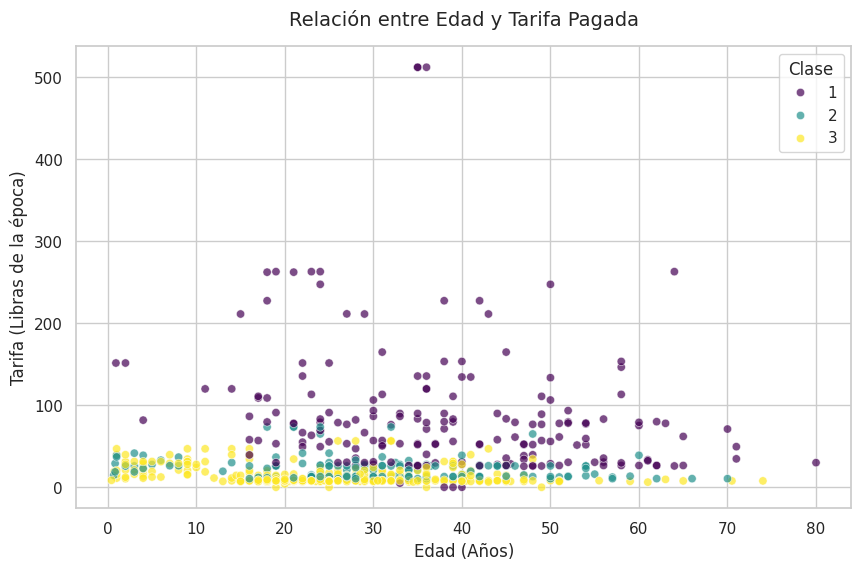

In [10]:
# Código Python - Pregunta 6
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Pclass', palette='viridis', alpha=0.7)

plt.title('Relación entre Edad y Tarifa Pagada', pad=15)
plt.xlabel('Edad (Años)')
plt.ylabel('Tarifa (Libras de la época)')
plt.legend(title='Clase')

plt.show()

**Interpretación**: No se aprecia una correlación lineal simple entre edad y riqueza (los puntos no forman una línea diagonal ascendente clara). Sin embargo, al estratificar por clase se observa un patrón: las tarifas más caras están concentradas casi exclusivamente en pasajeros de Primera Clase de rangos de edad muy variados, existiendo una base horizontal densa en la parte inferior que corresponde a las clases trabajadoras sin importar su edad.

**PARTE III: La Noche del Hundimiento**


**Pregunta 7**: ¿Cuál fue la tasa de supervivencia global?
Justificación del gráfico: Un Gráfico de Tarta (Pie Chart) o un gráfico de barras porcentual. El gráfico de tarta es perfecto aquí porque mapea de forma intuitiva las partes de un todo, dejando en claro el peso relativo (proporción) de supervivientes frente a fallecidos.

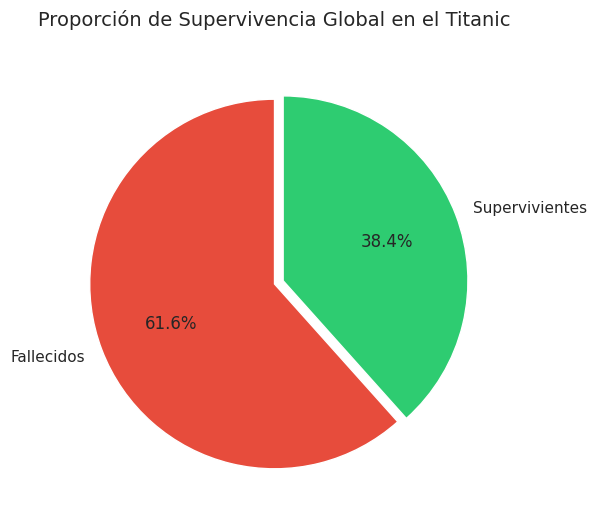

In [12]:
# Código Python - Pregunta 7
plt.figure(figsize=(6, 6))
survived_counts = df['Survived'].value_counts()

plt.pie(survived_counts, labels=['Fallecidos', 'Supervivientes'], autopct='%1.1f%%',
        startangle=90, colors=['#e74c3c', '#2ecc71'], explode=(0, 0.05))

plt.title('Proporción de Supervivencia Global en el Titanic', pad=20)
plt.show()

**Interpretación**: La tasa de supervivencia global fue trágicamente baja. Más de un siglo después, los datos confirman de forma cruda que el 61.6% de las personas a bordo perdieron la vida, mientras que sólo un 38.4% logró salvarse en los botes.

**Pregunta 8**: ¿Importó la clase social para sobrevivir?
Justificación del gráfico: Un Gráfico de Barras Agrupado (Barplot de conteo o proporción). Permite contrastar de manera simultánea tanto las cantidades absolutas como las proporciones relativas de supervivencia dentro de cada clase social.

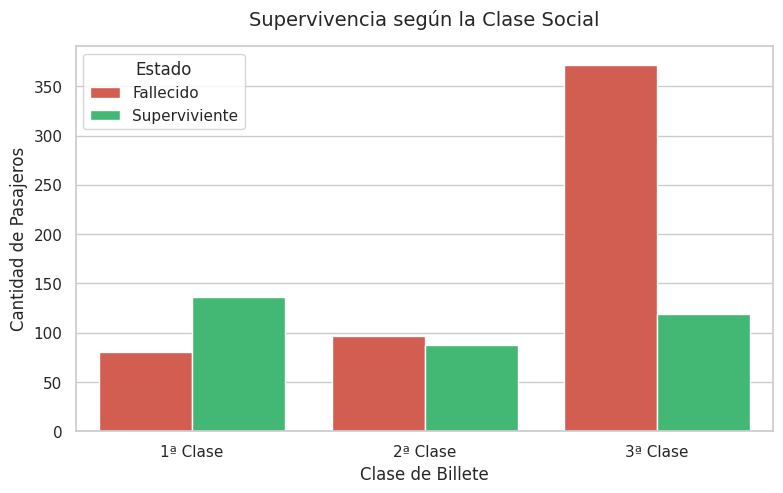

In [13]:
# Código Python - Pregunta 8
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df, x='Pclass', hue='Survived', palette=['#e74c3c', '#2ecc71'])

plt.title('Supervivencia según la Clase Social', pad=15)
plt.xlabel('Clase de Billete')
plt.ylabel('Cantidad de Pasajeros')
plt.xticks([0, 1, 2], ['1ª Clase', '2ª Clase', '3ª Clase'])
plt.legend(title='Estado', labels=['Fallecido', 'Superviviente'])

plt.show()

**Interpretación**: La clase social fue un factor absolutamente determinante para sobrevivir. En Primera Clase, la proporción de supervivientes es drásticamente mayor que la de fallecidos. En contraparte, en Tercera Clase la situación se invierte de forma dramática, falleciendo la inmensa mayoría de sus pasajeros debido a las barreras de acceso y localización de los botes descritas históricamente

**Pregunta 9**: ¿Se cumplió el protocolo 'mujeres y niños primero'?
Justificación del gráfico: Utilizaremos un Gráfico de Barras Facetado (Catplot / FacetGrid). Es ideal porque requerimos cruzar 3 variables simultáneamente: Sexo (Sex), Supervivencia (Survived) y Clase (Pclass)

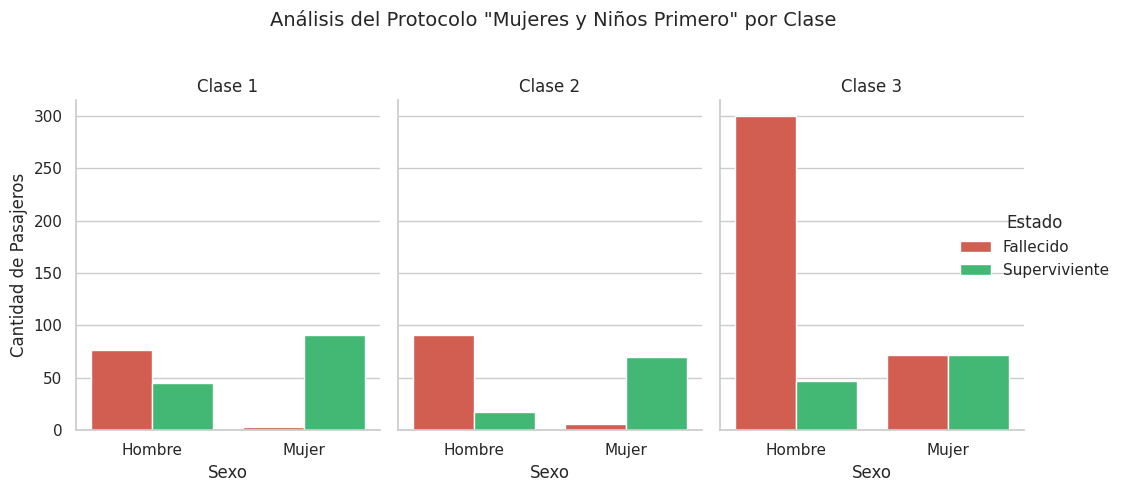

In [14]:
# Código Python - Pregunta 9
g = sns.catplot(
    data=df, x='Sex', hue='Survived', col='Pclass',
    kind='count', palette=['#e74c3c', '#2ecc71'], height=5, aspect=0.7
)

g.set_axis_labels("Sexo", "Cantidad de Pasajeros")
g.set_xticklabels(["Hombre", "Mujer"])
g.set_titles("Clase {col_name}")
g._legend.set_title("Estado")
new_labels = ['Fallecido', 'Superviviente']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

plt.subplots_adjust(top=0.8)
g.fig.suptitle('Análisis del Protocolo "Mujeres y Niños Primero" por Clase', fontsize=14)

plt.show()

**Interpretación**: El protocolo se cumplió de forma muy evidente si miramos el género: en todas las clases, las mujeres tuvieron tasas de supervivencia radicalmente superiores a las de los hombres. Sin embargo, el factor socioeconómico alteró el protocolo: una mujer de Tercera Clase tenía muchas más probabilidades de fallecer que una mujer de Primera o Segunda Clase, lo que demuestra la intersección crítica entre género y estatus social durante la evacuación.

**Pregunta 10**: ¿Tuvo la edad algún papel en la supervivencia?
Justificación del gráfico: Utilizaremos curvas de Gráfico de Densidad superpuestas (KDE Plot) segregadas por el estado de supervivencia. Esto permite comparar los perfiles continuos de edad de los que vivieron frente a los que murieron.

/tmp/ipykernel_1226/4264211733.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Survived']==1]['Age'], label='Superviviente', shade=True, color='#2ecc71')
/tmp/ipykernel_1226/4264211733.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Survived']==0]['Age'], label='Fallecido', shade=True, color='#e74c3c')


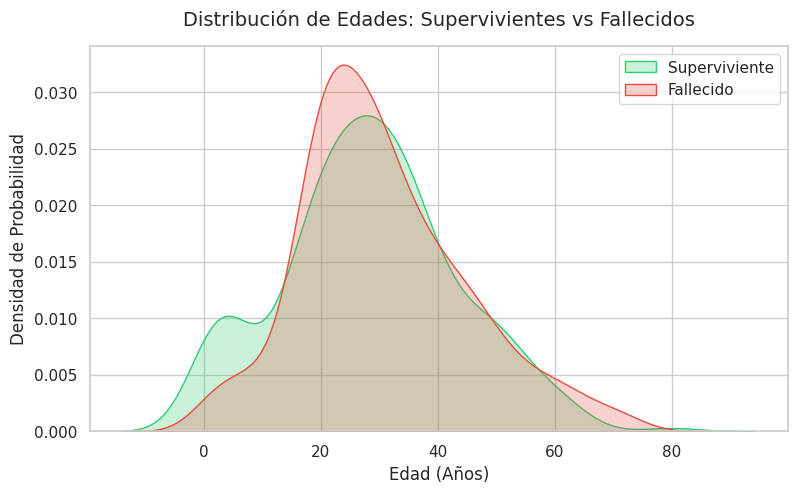

In [15]:
# Código Python - Pregunta 10
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df[df['Survived']==1]['Age'], label='Superviviente', shade=True, color='#2ecc71')
sns.kdeplot(data=df[df['Survived']==0]['Age'], label='Fallecido', shade=True, color='#e74c3c')

plt.title('Distribución de Edades: Supervivientes vs Fallecidos', pad=15)
plt.xlabel('Edad (Años)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()

plt.show()

**Interpretación**: La edad jugó un papel crucial en los extremos. En el rango de 0 a 10 años (niños), la curva verde de supervivencia supera con creces a la roja, confirmando que se priorizó la salvación de la infancia. Por el contrario, en los rangos de edad avanzada y jóvenes adultos, las tasas de fallecimiento son consistentemente dominantes.

**PARTE IV: Patrones Cruzados y Correlaciones**


Pregunta 11: ¿Qué variables numéricas están más relacionadas entre sí?
Justificación del gráfico: Un Mapa de Calor de Correlación (Heatmap) basado en la matriz de correlación de Pearson. Permite inspeccionar numéricamente y por colores todas las relaciones lineales cruzadas entre múltiples variables en un solo vistazo.

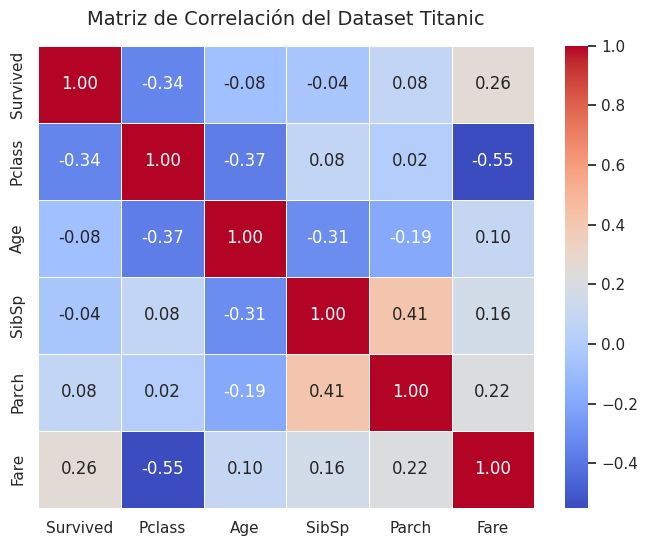

In [16]:
# Código Python - Pregunta 11
plt.figure(figsize=(8, 6))

# Seleccionamos las variables numéricas indicadas en el ejercicio
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación del Dataset Titanic', pad=15)

plt.show()

**Interpretación**: La relación más fuerte se da entre Fare (tarifa) y Pclass (clase), con una correlación negativa significativa (-0.55), lo cual es lógico ya que a menor número de clase (1ª clase), mayor era el precio del billete. Otra correlación interesante y lógica ocurre entre SibSp y Parch (0.41), indicando que quienes viajaban con hermanos/cónyuges también solían viajar con padres/hijos (estructuras familiares)

**Pregunta 12**: ¿Dónde embarcaron los pasajeros que sobrevivieron?

Justificación del gráfico: Un Gráfico de Barras de Factorización Gráfica (Pointplot o Barplot Embebido) cruzando el puerto de embarque con la tasa de supervivencia, desglosado por clases.

/tmp/ipykernel_1226/3068908937.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Embarked', y='Survived', hue='Pclass', palette='cubehelix', ci=None)


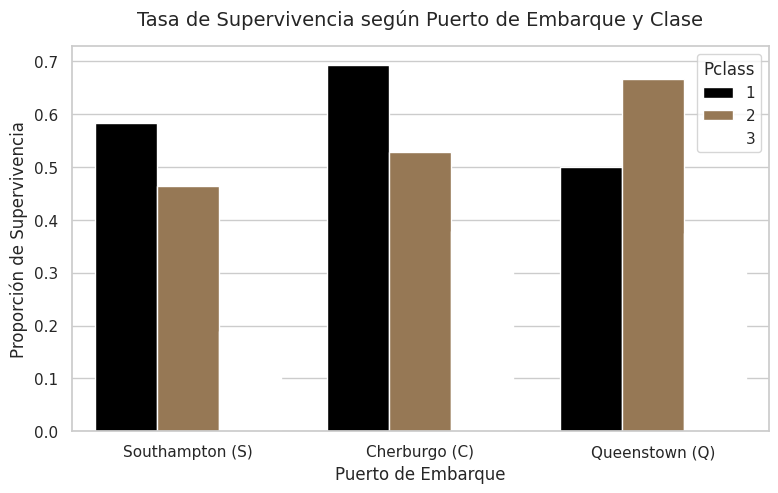

In [17]:
# Código Python - Pregunta 12
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='Embarked', y='Survived', hue='Pclass', palette='cubehelix', ci=None)

plt.title('Tasa de Supervivencia según Puerto de Embarque y Clase', pad=15)
plt.xlabel('Puerto de Embarque')
plt.ylabel('Proporción de Supervivencia')
plt.xticks([0, 1, 2], ['Southampton (S)', 'Cherburgo (C)', 'Queenstown (Q)']) #

plt.show()

**Interpretación**: Los pasajeros que embarcaron en Cherburgo (C) tuvieron, en promedio, una mejor tasa de supervivencia general. La razón detrás de esto no es geográfica, sino socioeconómica: en Cherburgo embarcó una proporción sustancialmente mayor de pasajeros adinerados de Primera Clase, mientras que en Queenstown (Q) e Inglaterra dominaba el pasaje de Tercera Clase.

**Pregunta 13**: ¿Viajar en familia protegía o perjudicaba?

Justificación del gráfico: Crearemos una nueva variable llamada FamilySize (Tamaño Familiar) sumando SibSp + Parch + 1 (el propio pasajero) , y utilizaremos un Gráfico de Línea o Barras (Lineplot / Barplot) para ver la tendencia de la tasa de supervivencia según el tamaño del grupo.

/tmp/ipykernel_1226/2713316513.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='FamilySize', y='Survived', color='royalblue', ci=None)


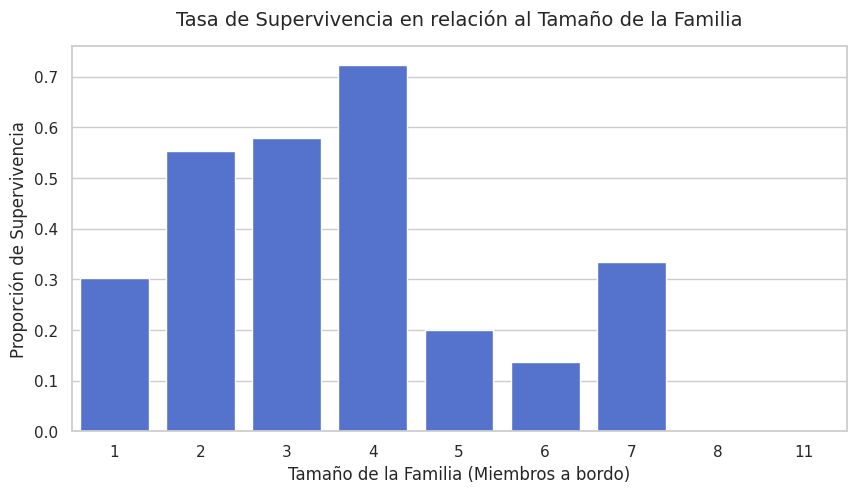

In [18]:
# Código Python - Pregunta 13
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1 #

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='FamilySize', y='Survived', color='royalblue', ci=None)

plt.title('Tasa de Supervivencia en relación al Tamaño de la Familia', pad=15)
plt.xlabel('Tamaño de la Familia (Miembros a bordo)')
plt.ylabel('Proporción de Supervivencia')

plt.show()

**Interpretación**: Los datos revelan un patrón en forma de campana: viajar completamente solo (tamaño = 1) suponía una desventaja clara en comparación con viajar en familias pequeñas (de 2 a 4 miembros), quienes obtuvieron los mejores índices de salvación. Sin embargo, para familias numerosas (5 o más miembros), la tasa se desploma drásticamente, respaldando la hipótesis histórica de que los grupos grandes sufrieron problemas logísticos y de separación trágicos durante el pánico del hundimiento.

**PARTE V: Dashboard del InvestigadorPregunta 14**: Dashboard de Síntesis Visual Diseñamos un lienzo unificado usando plt.subplots con una cuadrícula de $2 \times 2$ (4 gráficos clave) para resumir de forma autónoma la historia del Titanic.

/tmp/ipykernel_1226/316343620.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(ax=axes[0, 0], data=df, x='Pclass', y='Survived', palette='Oranges_r', ci=None)
/tmp/ipykernel_1226/316343620.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], data=df, x='Pclass', y='Survived', palette='Oranges_r', ci=None)
/tmp/ipykernel_1226/316343620.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['1ª Clase', '2ª Clase', '3ª Clase'])
/tmp/ipykernel_1226/316343620.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(ax=axes[0, 1], data=df, x='Sex', y='Survived', palette='Purples', ci=None)
/tmp/ipykerne

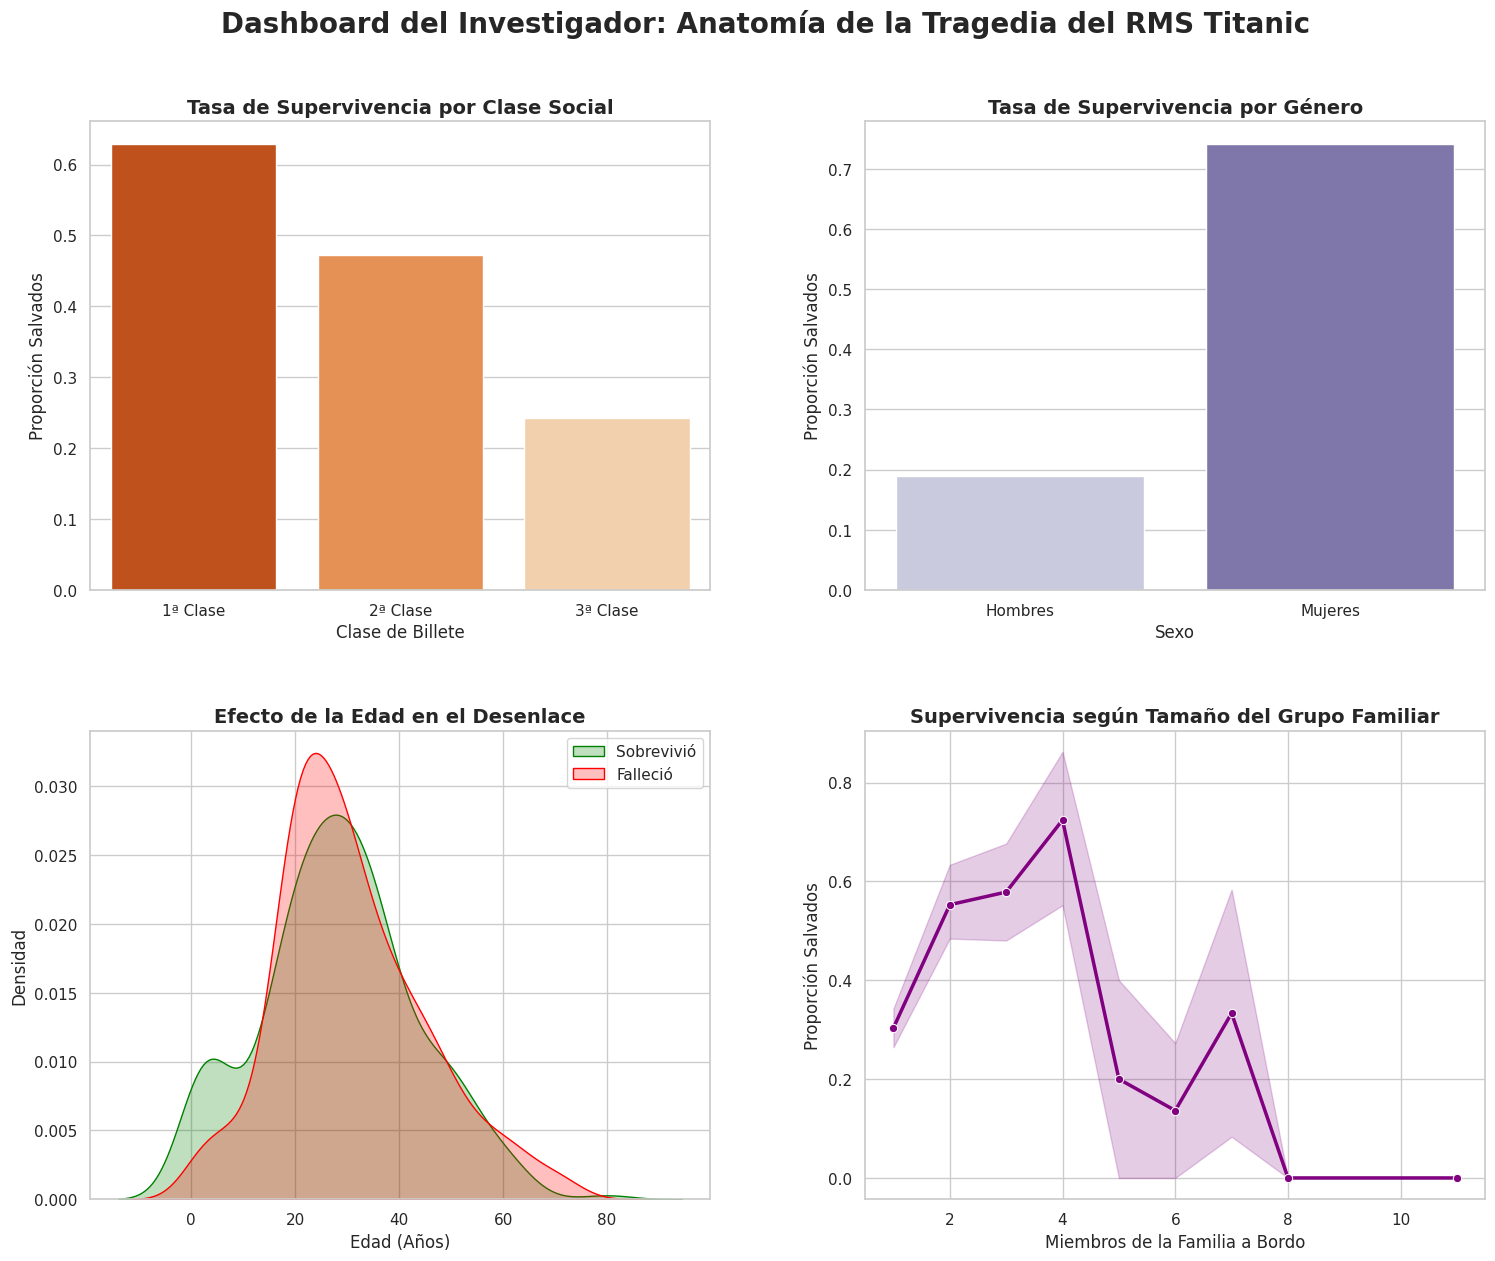

In [19]:
# Crear la estructura espacial del Dashboard (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Dashboard del Investigador: Anatomía de la Tragedia del RMS Titanic', fontsize=20, weight='bold', y=0.96) # [cite: 157]

# Subplot 1: Impacto de la Clase Social (Socioeconomía)
sns.barplot(ax=axes[0, 0], data=df, x='Pclass', y='Survived', palette='Oranges_r', ci=None)
axes[0, 0].set_title('Tasa de Supervivencia por Clase Social', weight='bold')
axes[0, 0].set_xlabel('Clase de Billete')
axes[0, 0].set_ylabel('Proporción Salvados')
axes[0, 0].set_xticklabels(['1ª Clase', '2ª Clase', '3ª Clase'])

# Subplot 2: El factor Género (Protocolo)
sns.barplot(ax=axes[0, 1], data=df, x='Sex', y='Survived', palette='Purples', ci=None)
axes[0, 1].set_title('Tasa de Supervivencia por Género', weight='bold')
axes[0, 1].set_xlabel('Sexo')
axes[0, 1].set_ylabel('Proporción Salvados')
axes[0, 1].set_xticklabels(['Hombres', 'Mujeres'])

# Subplot 3: Curva de Edades (Demografía)
sns.kdeplot(ax=axes[1, 0], data=df[df['Survived']==1]['Age'], label='Sobrevivió', shade=True, color='green')
sns.kdeplot(ax=axes[1, 0], data=df[df['Survived']==0]['Age'], label='Falleció', shade=True, color='red')
axes[1, 0].set_title('Efecto de la Edad en el Desenlace', weight='bold')
axes[1, 0].set_xlabel('Edad (Años)')
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].legend()

# Subplot 4: El núcleo Familiar (Logística de Evacuación)
sns.lineplot(ax=axes[1, 1], data=df, x='FamilySize', y='Survived', marker='o', color='purple', linewidth=2.5)
axes[1, 1].set_title('Supervivencia según Tamaño del Grupo Familiar', weight='bold')
axes[1, 1].set_xlabel('Miembros de la Familia a Bordo')
axes[1, 1].set_ylabel('Proporción Salvados')

# Ajustes de espaciado dinámico
plt.subplots_adjust(hspace=0.3, wspace=0.25)
plt.show()

**Historia Visual**

Resumen de Hallazgos: El análisis de los datos demuestra que la supervivencia en el Titanic no dependió de la suerte. Si eras una mujer viajando en Primera Clase o un niño pequeño, tus probabilidades de salir con vida eran prioritarias gracias al protocolo de evacuación. Por el contrario, los hombres, los pasajeros de Tercera Clase que sufrieron barreras de aislamiento, y las familias numerosas que se negaron a separarse en el caos, se llevaron la peor y más trágica parte de la noche.

**Reflexión Final**

1. ¿Qué gráfico te resultó más difícil de elegir? ¿Por qué? El de la pregunta 9 (cruzar género, clase y supervivencia). Requiere pensar en tres dimensiones al mismo tiempo, obligándonos a recurrir a la separación por facetas en lugar de un único eje estándar.  

2. ¿Hubo alguna pregunta donde varios tipos de gráfico eran igualmente válidos? ¿Cuál elegiste al final y por qué? Sí, en la pregunta 1 (composición del pasaje) y en la 7 (tasa global), donde se podían utilizar gráficos de tarta o de barras indistintamente. Elegí el gráfico de tarta para la tasa de supervivencia global porque destaca de manera inmediata la relación de fracciones de un total de $100\%$.  

3. ¿Qué hallazgo de los datos te sorprendió más? El impacto del tamaño de la familia. Intuitivamente se podría pensar que viajar con más familiares te daría más protección, pero los datos prueban de manera tajante que a partir de 5 miembros la probabilidad de morir aumentaba exponencialmente, debido a la dificultad extrema de coordinarse en una situación de pánico absoluto